# In-Class Activity: Diabetes Prediction with a Custom `nn.Module`

## Task
You will repeat the exact same workflow as Lab 4, but on a **new dataset** and **on your own**:
the **Pima Indians Diabetes dataset** — 8 numeric health measurements per patient, predicting
whether the patient has diabetes (`Outcome`: 1) or not (`Outcome`: 0).

Pipeline (identical structure to the lab you just did):

`raw data → train/test split → feature scaling → tensors → custom nn.Module (nn.Linear + nn.Sigmoid) → training loop → evaluation → loss plot`

Fill in every `# TODO`. Where you see `raise NotImplementedError`, replace the whole line with your code.

## Step 1: Imports

In [3]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# TODO: set a manual seed for reproducibility (torch.manual_seed)
torch.manual_seed(42)

## Step 2: Load & inspect the data

The CSV has **no header row**, so we supply column names ourselves. The last column,
`Outcome`, is already numeric (0 = no diabetes, 1 = diabetes) — unlike the lab, you will
**not** need a `LabelEncoder` here.

In [4]:
columns = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
           'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv'
df = pd.read_csv(url, names=columns)
df.head()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [5]:
# TODO: print df.shape — how many patients (rows) and features (columns)?
df.shape

(768, 9)

## Step 3: Train/test split

Split BEFORE any scaling, exactly like the lab — 20% test, and set `random_state` so
your results are reproducible.

In [6]:
# TODO: split df into X (all columns except 'Outcome') and y (the 'Outcome' column),
# then train_test_split with test_size=0.2 and a random_state
X=df.drop('Outcome',axis=1)
y=df['Outcome']
# X_train, X_test, y_train, y_test = train_test_split(...)
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

## Step 4: Feature scaling

Same reasoning as the lab: features here are on very different scales
(`Pregnancies` is roughly 0–15, `Insulin` can be in the hundreds). Standardize them.

In [7]:
# TODO: create a StandardScaler, fit_transform on X_train, transform (NOT fit_transform) on X_test
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Step 5: NumPy arrays → PyTorch tensors

> **Remember the pitfall from the lab:** cast to `float32` with `.astype(np.float32)`
> *before* `torch.from_numpy(...)`, or you'll hit a `Double` vs `Float` RuntimeError.

In [39]:
# TODO: convert X_train, X_test, y_train, y_test into
# X_train_tensor, X_test_tensor, y_train_tensor, y_test_tensor
X_train_tensor = torch.from_numpy(X_train.astype(np.float32))
X_test_tensor = torch.from_numpy(X_test.astype(np.float32))
y_train_tensor = torch.from_numpy(y_train.values.astype(np.float32))
y_test_tensor = torch.from_numpy(y_test.values.astype(np.float32))
# note: y_train / y_test are pandas Series here — call .values before .astype(np.float32)

print("X_train_tensor:", X_train_tensor.shape)
print("y_train_tensor:", y_train_tensor.shape)


X_train_tensor: torch.Size([614, 8])
y_train_tensor: torch.Size([614])


## Step 6: Model — custom `nn.Module`

Build a class `DiabetesClassifier` that mirrors `MySimpleNN` from the lab:
- one `nn.Linear` layer mapping `num_features → 1`
- one `nn.Sigmoid` activation
- a `forward()` method chaining them

In [44]:
class DiabetesClassifier(nn.Module):

  def __init__(self, num_features):
    super().__init__()
    # TODO: define self.linear and self.sigmoid
    self.linear=nn.Linear(num_features,1)
    self.sigmoid=nn.Sigmoid()

  def forward(self, features):
    out=self.linear(features)
    out=self.sigmoid(out)
    # TODO: pass features through linear, then sigmoid, and return the result
    return out


## Step 7: Hyperparameters & loss function

In [45]:
learning_rate = 0.1
epochs = 25

# TODO: create loss_function using nn.BCELoss()
loss_function = nn.BCELoss()

## Step 8: Training loop

Same five steps as the lab, in the same order:
forward pass → compute loss (watch the `.view(-1, 1)` shape pitfall!) → `zero_grad()` →
`backward()` → `step()`.

In [46]:
# TODO: instantiate the model — model = DiabetesClassifier(num_features)
model=DiabetesClassifier(X_train_tensor.shape[1])
# TODO: create optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
optimizer=torch.optim.SGD(model.parameters(),lr=learning_rate)
train_losses = []

for epoch in range(epochs):
  y_pred=model(X_train_tensor)
  loss=loss_function(y_pred,y_train_tensor.view(-1,1))
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()
  # TODO: forward pass
  # TODO: compute loss (remember to reshape the target)
  # TODO: zero_grad, backward, step

  train_losses.append(loss.item())
  print(f'Epoch: {epoch + 1}, Loss: {loss.item()}')


Epoch: 1, Loss: 0.6342277526855469
Epoch: 2, Loss: 0.6269400119781494
Epoch: 3, Loss: 0.620085597038269
Epoch: 4, Loss: 0.6136326193809509
Epoch: 5, Loss: 0.6075524687767029
Epoch: 6, Loss: 0.6018184423446655
Epoch: 7, Loss: 0.596406102180481
Epoch: 8, Loss: 0.5912928581237793
Epoch: 9, Loss: 0.5864579677581787
Epoch: 10, Loss: 0.5818823575973511
Epoch: 11, Loss: 0.577548623085022
Epoch: 12, Loss: 0.5734401941299438
Epoch: 13, Loss: 0.569542407989502
Epoch: 14, Loss: 0.5658413171768188
Epoch: 15, Loss: 0.5623244047164917
Epoch: 16, Loss: 0.5589797496795654
Epoch: 17, Loss: 0.5557965636253357
Epoch: 18, Loss: 0.5527647733688354
Epoch: 19, Loss: 0.5498750805854797
Epoch: 20, Loss: 0.5471189022064209
Epoch: 21, Loss: 0.544488251209259
Epoch: 22, Loss: 0.5419757962226868
Epoch: 23, Loss: 0.5395744442939758
Epoch: 24, Loss: 0.5372779965400696
Epoch: 25, Loss: 0.5350803732872009


## Step 9: Evaluation

Wrap this in `torch.no_grad()`. Use a 0.5 threshold to convert probabilities to class labels,
then compute accuracy.

In [47]:
# TODO: evaluate on X_test_tensor under torch.no_grad(), threshold at 0.5,
# compare against y_test_tensor.view(-1, 1), print accuracy
with torch.no_grad():
  y_pred = model(X_test_tensor)
  y_pred_labels = (y_pred > 0.5).float()
  accuracy = (y_pred_labels == y_test_tensor.view(-1, 1)).float().mean()
  print(f'Accuracy: {accuracy.item()}')

Accuracy: 0.7207792401313782


## Step 10: Plot the training loss curve

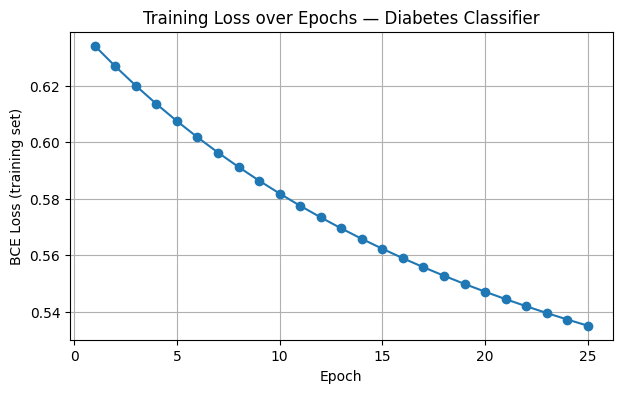

In [48]:
# TODO: plot train_losses vs epoch number, with axis labels and a title
plt.figure(figsize=(7, 4))
plt.plot(range(1, epochs + 1), train_losses, marker='o')
plt.xlabel('Epoch')
plt.ylabel('BCE Loss (training set)')
plt.title('Training Loss over Epochs — Diabetes Classifier')
plt.grid(True)
plt.show()

---
### Reflection (answer briefly once done)
1. How does your final accuracy compare to the breast-cancer lab's accuracy? Any guess why they differ?
2. Which line in your training loop would break first if you forgot `optimizer.zero_grad()` — and what symptom would you see in the loss curve?
